# Note: to save storage space, we do not include the matched fiducial marker coordinates output by the data processing workflows, but we show how they were processed to produce Supplementary Figure 5D in this notebook for transparency.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [2]:
img_alignment_rmses = []
for ch in [488, 561, 643]:
    for pos in range(7):
        ref_loocv = pd.read_csv('sfp_nih3t3_2019/alignment_errors_rep1/loov_errors_ch_{ch}_pos_{pos}.csv'.format(ch=ch, pos=pos))
        ref_loocv["sse"] = ref_loocv["x_diff"]**2 +  ref_loocv["y_diff"]**2
        alignment_ref_ch_rmses = np.sqrt(ref_loocv.groupby('hyb').mean().loc[:, 'sse'])
        img_alignment_rmses.append(alignment_ref_ch_rmses)

    for pos in range(10):
        ref_loocv = pd.read_csv('sfp_nih3t3_2019/alignment_errors_rep2/loov_errors_ch_{ch}_pos_{pos}.csv'.format(ch=ch, pos=pos))
        ref_loocv["sse"] = ref_loocv["x_diff"]**2 +  ref_loocv["y_diff"]**2
        alignment_ref_ch_rmses = np.sqrt(ref_loocv.groupby('hyb').mean().loc[:, 'sse'])
        img_alignment_rmses.append(alignment_ref_ch_rmses)

sfp_2019_concat_img_rmses = pd.concat(img_alignment_rmses)
sfp_2019_concat_img_rmses.name = "rmse"

In [3]:
sfp_2019_concat_img_rmses *= 103 #nm/pixel

In [4]:
np.mean(sfp_2019_concat_img_rmses)

np.float64(27.580243931345446)

In [5]:
np.median(sfp_2019_concat_img_rmses)

np.float64(24.158875982769437)

Text(0, 0.5, 'ECDF of images')

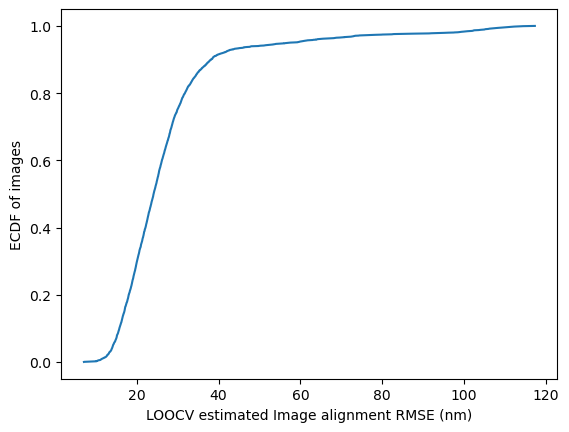

In [6]:
plt.plot(np.sort(sfp_2019_concat_img_rmses), np.linspace(0,1,len(sfp_2019_concat_img_rmses)))
plt.xlabel("LOOCV estimated Image alignment RMSE (nm)")
plt.ylabel("ECDF of images")

In [7]:
img_alignment_rmses = []
for pos in range(77):
    if pos not in [9,10, 11,12,13,27,32]: #bad fovs
        ref_loocv = pd.read_csv('mouse_cortex_alignment/loov_errors_pos_{pos}.csv'.format(pos=pos))
        ref_loocv["sse"] = ref_loocv["x_diff"]**2 +  ref_loocv["y_diff"]**2
        alignment_ref_ch_rmses = np.sqrt(ref_loocv.groupby('hyb').mean().loc[:, 'sse'])
        img_alignment_rmses.append(alignment_ref_ch_rmses)
        #print(len(alignment_sses) + len(alignment_ref_ch_sses))
mouse_cortex_concat_img_rmses = pd.concat(img_alignment_rmses)
mouse_cortex_concat_img_rmses *= 103 

In [8]:
mouse_cortex_concat_img_rmses.name= "rmse"

In [9]:
np.median(mouse_cortex_concat_img_rmses)

np.float64(29.494684669136685)

Text(0, 0.5, 'ECDF of images')

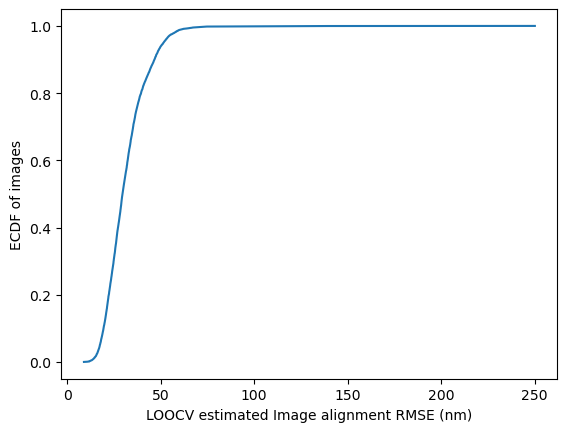

In [10]:
plt.plot(np.sort(mouse_cortex_concat_img_rmses), np.linspace(0,1,len(mouse_cortex_concat_img_rmses)))
plt.xlabel("LOOCV estimated Image alignment RMSE (nm)")
plt.ylabel("ECDF of images")

In [11]:
reg_loocv_path_temp = 'rs_xch_encoded_nih3t3/ref_cross_channel_loocv_pos{pos}.csv'
ref_ch_loov_path_temp = "rs_xch_encoded_nih3t3/loov_errors_ch{ch}_pos_{pos}.csv"


In [12]:
block_pc_hyb_ch_table = pd.read_csv("../Fig2D_ect/codebooks/block_pseudocolor_table.csv")
           # figure_generating_notebooks\Fig2D_ect\codebooks\block_pseudocolor_table.csv

In [13]:
img_alignment_rmses = []
for pos in range(31):
    #print("pos: ", pos)
    xch_loocv = pd.read_csv(reg_loocv_path_temp.format(pos=pos))
    xch_loocv = xch_loocv.loc[np.logical_not((xch_loocv.comp_ch == 2) & (xch_loocv.hyb_targetch > 32)),:]
    xch_loocv = xch_loocv.loc[np.logical_not((xch_loocv.hyb_targetch > 34)),:]

    xch_loocv["sse"] = xch_loocv["x_diff"]**2 +  xch_loocv["y_diff"]**2
    alignment_rmses = np.sqrt(xch_loocv.groupby(['hyb_targetch', 'comp_ch']).mean().loc[:, 'sse'])
    img_alignment_rmses.append(alignment_rmses)
    
    ref_ch  = list(set([1,2,3])  - set(np.unique(xch_loocv.comp_ch)))[0]
    #print("ref_ch: ", ref_ch)
    ref_loocv = pd.read_csv(ref_ch_loov_path_temp.format(pos=pos, ch = ref_ch-1))
    ref_loocv["sse"] = ref_loocv["x_diff"]**2 +  ref_loocv["y_diff"]**2
    alignment_ref_ch_rmses = np.sqrt(ref_loocv.groupby('hyb').mean().loc[:, 'sse'])
    alignment_ref_ch_rmses = alignment_ref_ch_rmses[block_pc_hyb_ch_table.loc[block_pc_hyb_ch_table.channel==ref_ch, "readout hyb"]-1]
    img_alignment_rmses.append(alignment_ref_ch_rmses)
    #print(len(alignment_sses) + len(alignment_ref_ch_sses))
xch_3t3_concat_img_rmses = pd.concat(img_alignment_rmses)
xch_3t3_concat_img_rmses *= 103 #nm/pixel
xch_3t3_concat_img_rmses.name = "rmse"

Text(0, 0.5, 'ECDF of images')

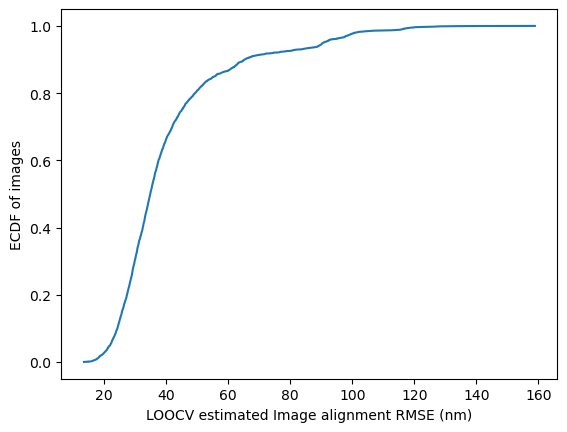

In [14]:
plt.plot(np.sort(xch_3t3_concat_img_rmses), np.linspace(0,1,len(xch_3t3_concat_img_rmses)))
plt.xlabel("LOOCV estimated Image alignment RMSE (nm)")
plt.ylabel("ECDF of images")

In [15]:
np.median(xch_3t3_concat_img_rmses)

np.float64(34.82764839276098)

In [16]:
sfp_2019_concat_img_rmses

hyb
0     81.286345
1     21.690602
2     75.878532
3     85.548849
4     89.711276
        ...    
76    41.856704
77    41.674656
78    34.619389
79    31.109571
80    36.415905
Name: rmse, Length: 4131, dtype: float64

In [17]:
sfp_2019_concat_img_rmses.to_csv("sfp2029_concat_img_rmses.csv")
mouse_cortex_concat_img_rmses.to_csv("mouse_cortex_concat_img_rmses.csv")
xch_3t3_concat_img_rmses.to_csv("xch_3t3_concat_img_rmses.csv")

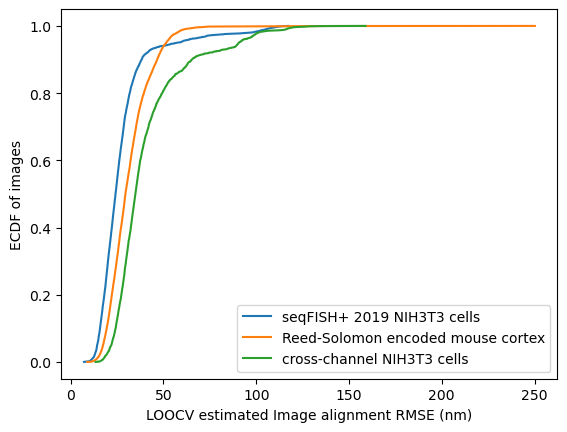

In [18]:
plt.plot(np.sort(sfp_2019_concat_img_rmses), np.linspace(0,1,len(sfp_2019_concat_img_rmses)), label="seqFISH+ 2019 NIH3T3 cells")
plt.plot(np.sort(mouse_cortex_concat_img_rmses), np.linspace(0,1,len(mouse_cortex_concat_img_rmses)), label="Reed-Solomon encoded mouse cortex")
plt.plot(np.sort(xch_3t3_concat_img_rmses), np.linspace(0,1,len(xch_3t3_concat_img_rmses)), label="cross-channel NIH3T3 cells")

plt.xlabel("LOOCV estimated Image alignment RMSE (nm)")
plt.ylabel("ECDF of images")
plt.legend()

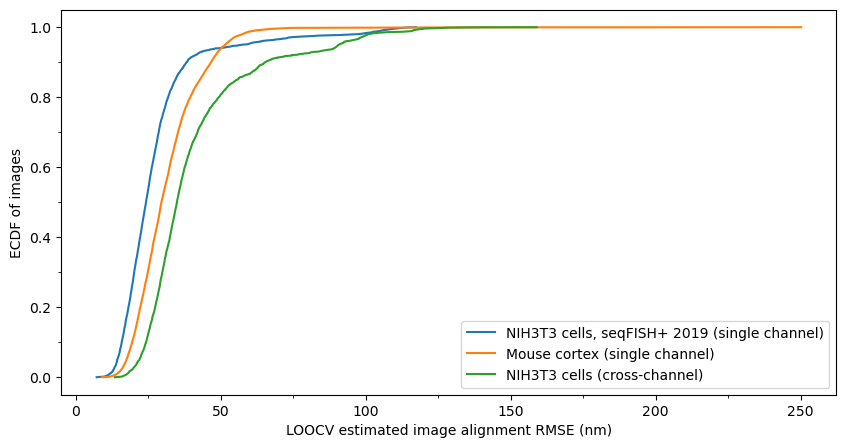

In [19]:
fig, ax = plt.subplots(1,1, figsize=(10,5))

ax.plot(np.sort(sfp_2019_concat_img_rmses), np.linspace(0,1,len(sfp_2019_concat_img_rmses)), label="NIH3T3 cells, seqFISH+ 2019 (single channel)")
ax.plot(np.sort(mouse_cortex_concat_img_rmses), np.linspace(0,1,len(mouse_cortex_concat_img_rmses)), label="Mouse cortex (single channel)")
ax.plot(np.sort(xch_3t3_concat_img_rmses), np.linspace(0,1,len(xch_3t3_concat_img_rmses)), label="NIH3T3 cells (cross-channel)")

ax.set_xticks([25, 75, 125, 175, 225], minor=True)
ax.set_yticks([0.1, 0.3, 0.5, 0.7, 0.9], minor=True)
ax.set_xlabel("LOOCV estimated image alignment RMSE (nm)")
ax.set_ylabel("ECDF of images")
ax.legend()
#plt.savefig("alignment_LOOCV_est_error_ECDFs.pdf")

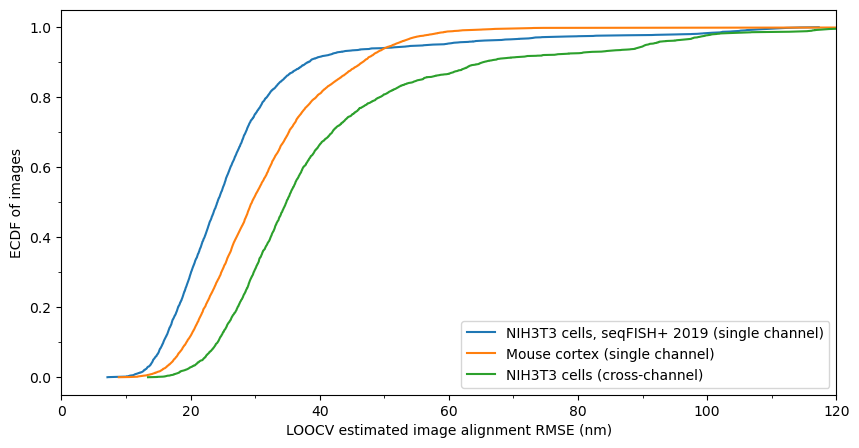

In [20]:
fig, ax = plt.subplots(1,1, figsize=(10,5))

ax.plot(np.sort(sfp_2019_concat_img_rmses), np.linspace(0,1,len(sfp_2019_concat_img_rmses)), label="NIH3T3 cells, seqFISH+ 2019 (single channel)")
ax.plot(np.sort(mouse_cortex_concat_img_rmses), np.linspace(0,1,len(mouse_cortex_concat_img_rmses)), label="Mouse cortex (single channel)")
ax.plot(np.sort(xch_3t3_concat_img_rmses), np.linspace(0,1,len(xch_3t3_concat_img_rmses)), label="NIH3T3 cells (cross-channel)")

ax.set_xticks([10, 30, 50, 70, 90, 110, 130], minor=True)
ax.set_yticks([0.1, 0.3, 0.5, 0.7, 0.9], minor=True)
ax.set_xlabel("LOOCV estimated image alignment RMSE (nm)")
ax.set_xlim(0, 120)
ax.set_ylabel("ECDF of images")
ax.legend()
plt.savefig("alignment_LOOCV_est_error_ECDFs.pdf")